# Marc — Arc Narratif (Analyse Morphologique)

Analyse de l'arc narratif de l'Évangile de Marc à partir de la **morphologie verbale grecque**,
en utilisant le dataset **N1904** (Nestle 1904, CenterBLC) via Text-Fabric.

## Qu'est-ce qu'un arc narratif ?

Un **[arc narratif](https://en.wikipedia.org/wiki/Story_arc)** est la courbe d'intensité d'un récit au fil du temps — l'équivalent littéraire d'un électrocardiogramme : là où le cœur bat fort, l'action se concentre ; là où il ralentit, le récit reprend son souffle, explique, enseigne ou médite.

Dans un roman policier, l'arc monte vers le dénouement et redescend après la révélation.

Dans une tragédie grecque, il suit la structure en cinq actes d'Aristote : exposition → montée de la tension → crise → chute → résolution. Dans un texte sacré, l'arc dit quelque chose de plus subtil : **là où le texte accumule des événements accomplis, il *raconte* ;
là où il accumule des exhortations et des questions, il *enseigne*.**

Ce que l'arc narratif révèle sur un texte :

- **Le rythme de l'auteur** : Marc écrit-il en rafales d'action courtes ou en longues méditations ?
- **La structure cachée** : y a-t-il des charnières narratives que le découpage en chapitres
  (ajouté au XIII<sup>e</sup> siècle !) ne fait pas voir ?
- **La singularité stylistique** : Marc est-il vraiment plus « haché » que Matthieu ou Luc,
  comme le disent les commentateurs depuis des siècles — et peut-on le *mesurer* ?

## Principe

Chaque verbe grec reçoit un score *réalis* ou *irréalis* selon son **mode** et son **temps** :

- **Réalis fort** (indicatif aoriste/parfait) : événements présentés comme accomplis, factuels — *densité narrative maximale*
- **Réalis continu** (indicatif présent/imparfait) : actions en cours ou habituelles — *toile de fond narrative*
- **Arrière-plan** (participes, indicatif plus-que-parfait) : circonstances et préconditions
- **Irréalis** (subjonctif, optatif, impératif, infinitif, futur) : potentiel, commandé, espéré — *discours et exhortation*

La moyenne de ces scores par chapitre trace une **courbe d'arc narratif** :

- un pic = chapitre dense en action accomplie
- un creux = chapitre de discours.

## Approche vs BookNLP

BookNLP ([Github](https://github.com/booknlp/booknlp)) dérive l'intensité narrative par heuristiques sémantiques (densité d'entités, de dialogues).
Cette approche est **morpho-aspectuelle** : elle repose sur les données philologiques vérifiées de N1904, non sur un modèle prédictif. Fondements théoriques : Porter & Fanning (aspect verbal grec), Fleischman (discourse analysis narrative).

## Extension

Le même pipeline tourne sur les 4 évangiles → figure comparative publiable
(Marc très aoristique, Jean creux ch.13-17 = Discours du Cénacle).

In [24]:
from tf.app import use
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.signal import savgol_filter

N1904 = use("CenterBLC/N1904", version="1.0.0", hoist=globals(), silent=True)

print("✅ Dataset N1904 chargé.")

**Locating corpus resources ...**

Display is setup for viewtype [syntax-view](https://github.com/saulocantanhede/tfgreek2/blob/main/docs/syntax-view.md#start)

See [here](https://github.com/saulocantanhede/tfgreek2/blob/main/docs/viewtypes.md#start) for more information on viewtypes

✅ Dataset N1904 chargé.


## REALIS_MAP — Table de classification réalis/irréalis

- Scores positifs = réalis (événement présenté comme effectivement accompli ou en cours)
- Scores négatifs = irréalis (événement potentiel, commandé, futur ou conditionnel)

Décisions exégétiques :
- L'indicatif aoriste (1.0) est le marqueur de réalité narrative par excellence en grec koinè :
  il présente un événement comme un point accompli dans le temps.
- L'indicatif futur (−0.3) est classé irréalis malgré son mode indicatif : il référencie
  un événement non encore réalisé au moment de l'énonciation.
- Les participes (0.4) sont ambigus : un participe aoriste en construction *attendant circumstance*
  (ἀπεκρίθη εἶπεν) porte sémantiquement la même valeur que le verbe principal. Ce cas est
  quantifié séparément à la Section 6.
- Les clés génériques (`mode`, `'*'`) s'appliquent à tous les temps pour les modes où le temps
  est aspectuellement secondaire (subjonctif, optatif, impératif, infinitif, participe).

In [25]:
REALIS_MAP = {
    # (mode, temps) -> (catégorie, poids)
    ("indicative", "aorist"):     ("realis_strong",    1.0),
    ("indicative", "present"):    ("realis_continuous", 0.7),
    ("indicative", "imperfect"):  ("realis_continuous", 0.6),
    ("indicative", "perfect"):    ("realis_strong",    0.9),
    ("indicative", "pluperfect"): ("realis_background", 0.5),
    ("indicative", "future"):     ("irrealis_future",  -0.3),
    ("subjunctive", "*"):         ("irrealis",         -0.5),
    ("optative", "*"):            ("irrealis",         -0.6),
    ("imperative", "*"):          ("irrealis_command", -0.4),
    ("infinitive", "*"):          ("irrealis_modal",   -0.2),
    ("participle", "*"):          ("realis_background", 0.4),
}

print(f"REALIS_MAP chargé — {len(REALIS_MAP)} entrées")

REALIS_MAP chargé — 11 entrées


## 1. Inspection des features morphologiques (Marc 1:2-5)

Vérification que les noms de features N1904 (`mood`, `tense`, `voice`) correspondent
aux clés de `REALIS_MAP`. Marc 1:1 n'ayant pas de verbe, on commence à 1:2.

In [26]:
rows = []
for v_num in range(2, 6):
    verse_node = T.nodeFromSection(('Mark', 1, v_num))
    words = L.d(verse_node, otype='word')
    for w in words:
        if F.sp.v(w) == 'verb' and len(rows) < 10:
            rows.append({
                "Réf":   f"Mc 1:{v_num}",
                "Texte": F.text.v(w),
                "Lemme": F.lemma.v(w),
                "Gloss": F.gloss.v(w),
                "Mode":  F.mood.v(w),
                "Temps": F.tense.v(w),
                "Voix":  F.voice.v(w),
                "Poids": REALIS_MAP.get(
                    (F.mood.v(w), F.tense.v(w)),
                    REALIS_MAP.get((F.mood.v(w), "*"), ("?", "?"))
                )[1],
            })

df_inspect = pd.DataFrame(rows)
display(df_inspect)

,Réf,Texte,Lemme,Gloss,Mode,Temps,Voix,Poids
0,Mc 1:2,γέγραπται,γράφω,write,indicative,perfect,passive,0.9
1,Mc 1:2,Ἰδοὺ,ὁράω,"see, look upon",imperative,aorist,middle,-0.4
2,Mc 1:2,ἀποστέλλω,ἀποστέλλω,"send away, dismiss, send out",indicative,present,active,0.7
3,Mc 1:2,κατασκευάσει,κατασκευάζω,"build, prepare, make, furnish",indicative,future,active,-0.3
4,Mc 1:3,βοῶντος,βοάω,"shout, call aloud, call",participle,present,active,0.4
5,Mc 1:3,Ἑτοιμάσατε,ἑτοιμάζω,"make ready, prepare",imperative,aorist,active,-0.4
6,Mc 1:3,ποιεῖτε,ποιέω,"do, make",imperative,present,active,-0.4
7,Mc 1:4,ἐγένετο,γίνομαι,"am born, become, happen",indicative,aorist,middle,1.0
8,Mc 1:4,βαπτίζων,βαπτίζω,"dip, baptize",participle,present,active,0.4
9,Mc 1:4,κηρύσσων,κηρύσσω,"proclaim, herald, preach",participle,present,active,0.4


## 2. Fonctions de scoring

In [27]:
def get_verb_weight(mood: str, tense: str):
    """
    Retourne (catégorie, poids) pour un verbe donné par son mode et son temps.
    Essaie d'abord la clé exacte (mood, tense), puis la clé générique (mood, '*').
    Retourne None si aucune entrée ne correspond (ne devrait pas arriver avec N1904).
    """
    key = (mood, tense)
    if key in REALIS_MAP:
        return REALIS_MAP[key]
    wildcard = (mood, "*")
    if wildcard in REALIS_MAP:
        return REALIS_MAP[wildcard]
    return None


def score_chapter(book: str, chapter_num: int) -> dict:
    """
    Calcule la composition réalis/irréalis et le score net pour un chapitre entier.

    Traversal : le nœud de chapitre (2-tuple sans verset) est plus efficace
    que la boucle verset-par-verset et retourne les mêmes mots.

    Normalisation : moyenne des poids sur les verbes classifiés uniquement
    (pas sur le total de mots) pour rendre les chapitres comparables
    indépendamment de leur longueur.

    Les sous-catégories irréalis (irrealis_future, irrealis_command, irrealis_modal)
    sont regroupées en 'irrealis' pour les pourcentages d'affichage.
    """
    chapter_node = T.nodeFromSection((book, chapter_num))
    words = L.d(chapter_node, otype='word')

    counts = {
        "realis_strong":     0,
        "realis_continuous": 0,
        "realis_background": 0,
        "irrealis":          0,
    }
    weights = []

    for w in words:
        if F.sp.v(w) != 'verb':
            continue
        result = get_verb_weight(F.mood.v(w), F.tense.v(w))
        if result is None:
            continue
        cat, weight = result
        weights.append(weight)
        # Regrouper les sous-catégories irréalis pour l'affichage
        display_cat = cat if cat in counts else "irrealis"
        counts[display_cat] += 1

    total = len(weights)
    net_score = sum(weights) / total if total else 0.0

    def pct(k):
        return round(counts[k] / total * 100, 1) if total else 0.0

    return {
        "chapter":               chapter_num,
        "net_score":             round(net_score, 4),
        "verb_count":            total,
        "realis_strong_pct":     pct("realis_strong"),
        "realis_continuous_pct": pct("realis_continuous"),
        "realis_background_pct": pct("realis_background"),
        "irrealis_pct":          pct("irrealis"),
    }


GOSPEL_CHAPTERS = {
    "Mark":     16,
    "Matthew":  28,
    "Luke":     24,
    "John":     21,
}


def build_gospel_df(book: str) -> pd.DataFrame:
    """
    Construit un DataFrame par chapitre pour un évangile donné.

    Colonnes : chapter, net_score, verb_count,
               realis_strong_pct, realis_continuous_pct,
               realis_background_pct, irrealis_pct
    """
    n = GOSPEL_CHAPTERS[book]
    rows = [score_chapter(book, ch) for ch in range(1, n + 1)]
    return pd.DataFrame(rows)


print("✅ Fonctions définies : get_verb_weight, score_chapter, build_gospel_df")

✅ Fonctions définies : get_verb_weight, score_chapter, build_gospel_df


## 3. DataFrame Marc — composition par chapitre

In [28]:
df_mark = build_gospel_df("Mark")

# Vérification : aucun chapitre sans verbe
assert df_mark["verb_count"].min() > 0, "Chapitre sans verbe détecté — vérifier le dataset"

max_ch = int(df_mark.loc[df_mark.net_score.idxmax(), "chapter"])
min_ch = int(df_mark.loc[df_mark.net_score.idxmin(), "chapter"])

print(f"Chapitre le plus réaliste  : ch.{max_ch} (net_score={df_mark.net_score.max():.3f})")
print(f"Chapitre le moins réaliste : ch.{min_ch} (net_score={df_mark.net_score.min():.3f})")
print()

styled = (
    df_mark.style
    .format({
        "net_score":             "{:.4f}",
        "realis_strong_pct":     "{:.1f}%",
        "realis_continuous_pct": "{:.1f}%",
        "realis_background_pct": "{:.1f}%",
        "irrealis_pct":          "{:.1f}%",
    })
    .background_gradient(subset=["net_score"], cmap="RdYlGn")
    .set_caption("Marc — Composition modale verbale par chapitre")
)
display(styled)

Chapitre le plus réaliste  : ch.15 (net_score=0.503)
Chapitre le moins réaliste : ch.13 (net_score=0.024)



,chapter,net_score,verb_count,realis_strong_pct,realis_continuous_pct,realis_background_pct,irrealis_pct
0,1,0.4776,161,26.7%,24.2%,29.8%,19.3%
1,2,0.4642,123,17.1%,43.1%,17.1%,22.8%
2,3,0.3568,118,16.1%,37.3%,14.4%,32.2%
3,4,0.3871,163,17.2%,42.3%,11.7%,28.8%
4,5,0.4751,173,24.3%,28.9%,27.7%,19.1%
5,6,0.4778,230,28.7%,26.5%,23.9%,20.9%
6,7,0.4551,127,17.3%,40.9%,20.5%,21.3%
7,8,0.4118,152,19.1%,34.2%,19.7%,27.0%
8,9,0.3947,209,21.1%,31.1%,20.1%,27.8%
9,10,0.3009,220,18.2%,27.3%,17.3%,37.3%


## 4. Composition modale par chapitre (stacked bar)

Chaque barre = 100% des verbes classifiés du chapitre, répartis en 4 catégories.

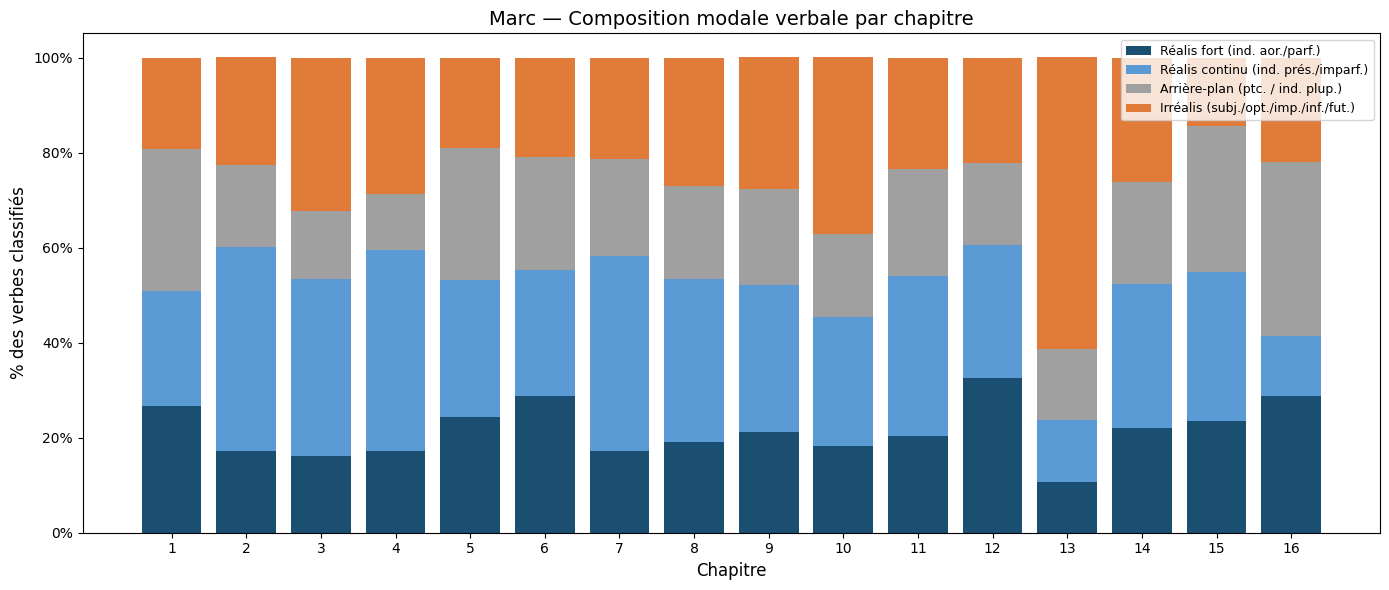

In [29]:
COLORS = {
    "realis_strong":     "#1a4f72",
    "realis_continuous": "#5b9bd5",
    "realis_background": "#a0a0a0",
    "irrealis":          "#e07b39",
}

STACK_COLS = [
    "realis_strong_pct",
    "realis_continuous_pct",
    "realis_background_pct",
    "irrealis_pct",
]

STACK_LABELS = [
    "Réalis fort (ind. aor./parf.)",
    "Réalis continu (ind. prés./imparf.)",
    "Arrière-plan (ptc. / ind. plup.)",
    "Irréalis (subj./opt./imp./inf./fut.)",
]

chapters = df_mark["chapter"].tolist()
bottom = [0.0] * len(chapters)

fig, ax = plt.subplots(figsize=(14, 6))

for col, label, color in zip(STACK_COLS, STACK_LABELS, COLORS.values()):
    vals = df_mark[col].tolist()
    ax.bar(chapters, vals, bottom=bottom, label=label, color=color, width=0.8)
    bottom = [b + v for b, v in zip(bottom, vals)]

ax.set_xlabel("Chapitre", fontsize=12)
ax.set_ylabel("% des verbes classifiés", fontsize=12)
ax.set_title("Marc — Composition modale verbale par chapitre", fontsize=14)
ax.set_xticks(chapters)
ax.legend(loc="upper right", fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

## 5. Arc narratif lissé

Le filtre de Savitzky-Golay (fenêtre=3, degré=2) lisse la courbe brute tout en préservant
les pics et creux — contrairement à une moyenne mobile qui les atténue.

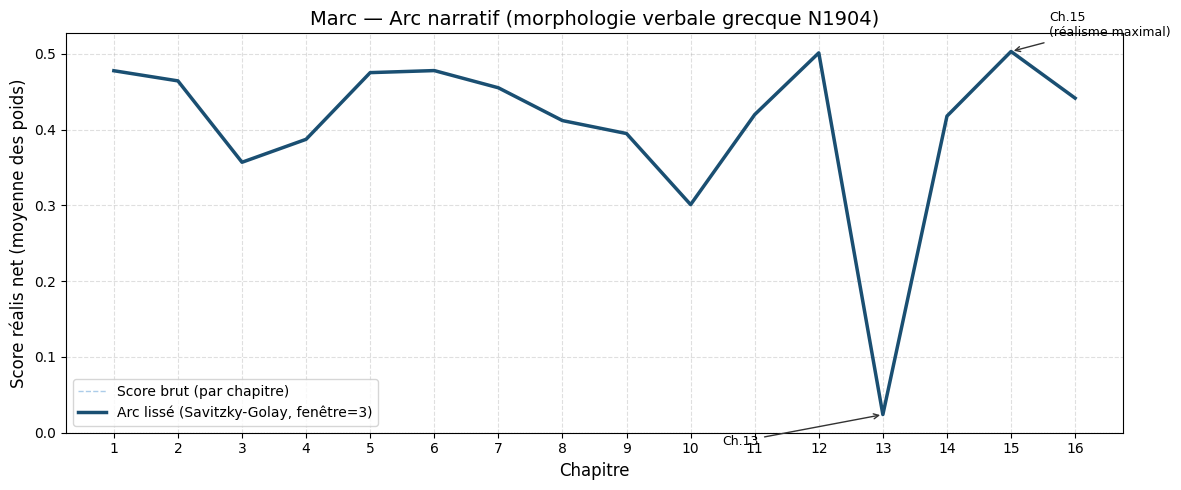

In [30]:
net_scores = df_mark["net_score"].values
smoothed = savgol_filter(net_scores, window_length=3, polyorder=2)

fig, ax = plt.subplots(figsize=(12, 5))

# Scores bruts (en arrière-plan)
ax.plot(chapters, net_scores,
        color="#5b9bd5", linewidth=1, linestyle="--", alpha=0.5,
        label="Score brut (par chapitre)")

# Courbe narrative lissée
ax.plot(chapters, smoothed,
        color="#1a4f72", linewidth=2.5,
        label="Arc lissé (Savitzky-Golay, fenêtre=3)")

# Annotations des extrêmes
ax.annotate(
    f"Ch.{max_ch}\n(réalisme maximal)",
    xy=(max_ch, smoothed[max_ch - 1]),
    xytext=(max_ch + 0.6, smoothed[max_ch - 1] + 0.02),
    fontsize=9, arrowprops=dict(arrowstyle="->", color="#333")
)
ax.annotate(
    f"Ch.{min_ch}",
    xy=(min_ch, smoothed[min_ch - 1]),
    xytext=(min_ch - 2.5, smoothed[min_ch - 1] - 0.04),
    fontsize=9, arrowprops=dict(arrowstyle="->", color="#333")
)

# Frontière réalis/irréalis
ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")

ax.set_xlabel("Chapitre", fontsize=12)
ax.set_ylabel("Score réalis net (moyenne des poids)", fontsize=12)
ax.set_title("Marc — Arc narratif (morphologie verbale grecque N1904)", fontsize=14)
ax.set_xticks(chapters)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 6. Cas particulier : participe aoriste avant verbe fini

Marc est riche en constructions du type **ἀπεκρίθη εἶπεν** (litt. « ayant répondu, il dit »),
où un participe aoriste fonctionne comme *attendant circumstance* — il porte la même valeur
aspectuelle que le verbe principal qui suit.

Dans `REALIS_MAP`, tous les participes reçoivent 0.4 (arrière-plan). Cette cellule quantifie
le nombre d'instances où ce score est potentiellement sous-estimé.

In [31]:
def detect_participle_before_main_verb(book: str) -> pd.DataFrame:
    """
    Détecte les instances d'un participe aoriste immédiatement suivi d'un verbe
    indicatif dans le flux séquentiel des verbes du livre.

    Utilise la liste séquentielle de verbes (et non L.n()) pour éviter
    la complexité des tuples de nœuds adjacents à granularités multiples.

    Retourne un DataFrame : Réf, Participe, Tps ptc, Vb principal, Tps vb, Mode vb
    """
    book_node = T.nodeFromSection((book,))
    all_words = L.d(book_node, otype='word')
    only_verbs = [w for w in all_words if F.sp.v(w) == 'verb']

    rows = []
    for i, w1 in enumerate(only_verbs[:-1]):
        w2 = only_verbs[i + 1]
        if (
            F.mood.v(w1) == 'participle'
            and F.tense.v(w1) == 'aorist'
            and F.mood.v(w2) == 'indicative'
        ):
            ref = T.sectionFromNode(w1)
            rows.append({
                "Réf":          f"{ref[0]} {ref[1]}:{ref[2]}",
                "Participe":    F.text.v(w1),
                "Tps ptc":      F.tense.v(w1),
                "Vb principal": F.text.v(w2),
                "Tps vb":       F.tense.v(w2),
                "Mode vb":      F.mood.v(w2),
            })

    return pd.DataFrame(rows)


df_ptc = detect_participle_before_main_verb("Mark")
print(f"Instances de participe aoriste avant verbe indicatif dans Marc : {len(df_ptc)}")
print(f"\nExemples (10 premiers) :")
display(df_ptc.head(10))
print()
print("Note : REALIS_MAP attribue 0.4 à tous les participes.")
print("Ces constructions mériteraient 1.0 (même valeur que leur verbe principal).")
print(f"Impact estimé : {len(df_ptc)} verbes sous-scorés sur {df_mark['verb_count'].sum()} au total.")

Instances de participe aoriste avant verbe indicatif dans Marc : 197

Exemples (10 premiers) :


,Réf,Participe,Tps ptc,Vb principal,Tps vb,Mode vb
0,Mark 1:18,ἀφέντες,aorist,ἠκολούθησαν,aorist,indicative
1,Mark 1:19,προβὰς,aorist,εἶδεν,aorist,indicative
2,Mark 1:20,ἀφέντες,aorist,ἀπῆλθον,aorist,indicative
3,Mark 1:21,εἰσελθὼν,aorist,ἐδίδασκεν,imperfect,indicative
4,Mark 1:26,φωνῆσαν,aorist,ἐξῆλθεν,aorist,indicative
5,Mark 1:29,ἐξελθόντες,aorist,ἦλθον,aorist,indicative
6,Mark 1:31,προσελθὼν,aorist,ἤγειρεν,aorist,indicative
7,Mark 1:31,κρατήσας,aorist,ἀφῆκεν,aorist,indicative
8,Mark 1:32,γενομένης,aorist,ἔδυσεν,aorist,indicative
9,Mark 1:35,ἀναστὰς,aorist,ἐξῆλθεν,aorist,indicative



Note : REALIS_MAP attribue 0.4 à tous les participes.
Ces constructions mériteraient 1.0 (même valeur que leur verbe principal).
Impact estimé : 197 verbes sous-scorés sur 2654 au total.


## 7. Comparaison des 4 évangiles

L'axe X est **normalisé (0→1)** pour aligner les courbes malgré les longueurs différentes
(Marc 16 ch., Matthieu 28 ch., Luc 24 ch., Jean 21 ch.).

Hypothèses exégétiques vérifiables computationnellement :
- **Marc** : courbe haute, dense en aoristes (style narratif haché)
- **Jean** : creux marqué aux ch.13-17 (Discours d'adieu : subjonctifs, impératifs)
- **Matthieu** : pic aux ch.5-7 = paradoxe (Sermon sur la Montagne = irréalis élevé)
- **Luc** : profil intermédiaire (narrateur + discours d'Actes similaire)

Traitement de Mark... OK
Traitement de Matthew... OK
Traitement de Luke... OK
Traitement de John... OK


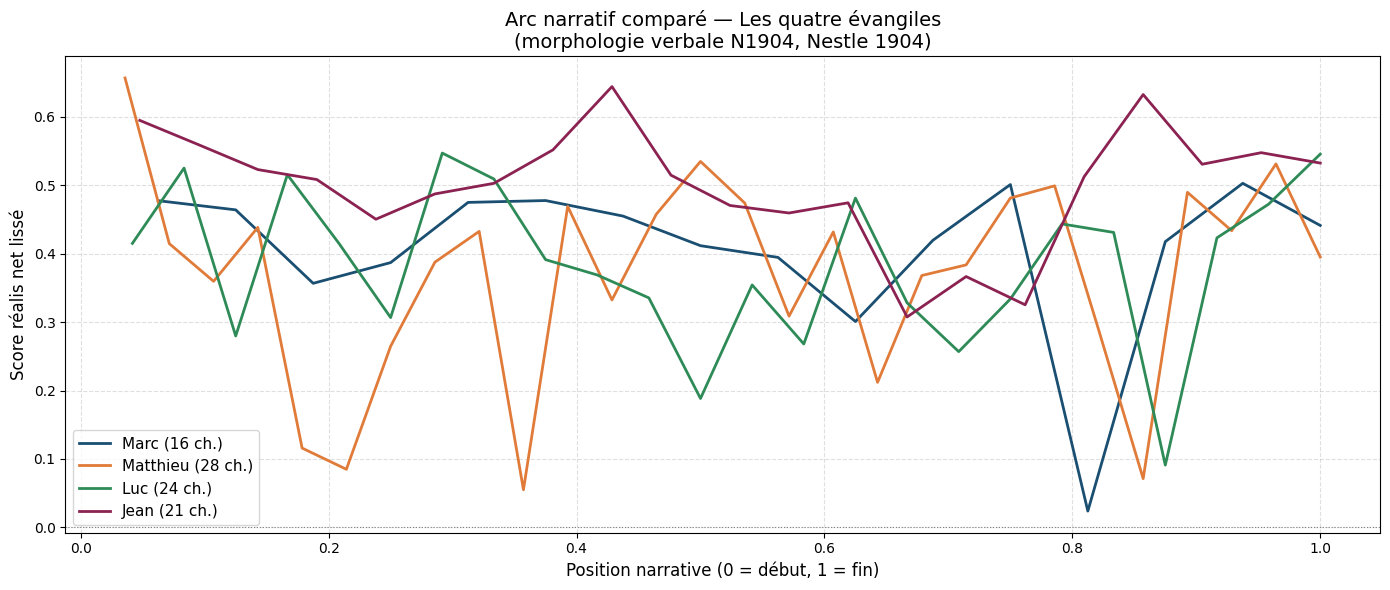

In [32]:
# Construction des DataFrames pour les 4 évangiles (~10 secondes)
dfs = {}
for book in ["Mark", "Matthew", "Luke", "John"]:
    print(f"Traitement de {book}...", end=" ")
    dfs[book] = build_gospel_df(book)
    print("OK")

GOSPEL_COLORS = {
    "Mark":    "#1a4f72",
    "Matthew": "#e07b39",
    "Luke":    "#2e8b57",
    "John":    "#8b2252",
}

GOSPEL_LABELS = {
    "Mark":    "Marc (16 ch.)",
    "Matthew": "Matthieu (28 ch.)",
    "Luke":    "Luc (24 ch.)",
    "John":    "Jean (21 ch.)",
}

fig, ax = plt.subplots(figsize=(14, 6))

for book, df in dfs.items():
    scores = df["net_score"].values
    n = len(scores)
    # Axe X normalisé : position narrative 0→1
    x_norm = [ch / n for ch in range(1, n + 1)]
    smoothed = savgol_filter(scores, window_length=3, polyorder=2)
    ax.plot(x_norm, smoothed,
            label=GOSPEL_LABELS[book],
            color=GOSPEL_COLORS[book],
            linewidth=2)

ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set_xlabel("Position narrative (0 = début, 1 = fin)", fontsize=12)
ax.set_ylabel("Score réalis net lissé", fontsize=12)
ax.set_title(
    "Arc narratif comparé — Les quatre évangiles\n(morphologie verbale N1904, Nestle 1904)",
    fontsize=14
)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 8. (Optionnel) Texte BJ pour les chapitres extrêmes

Le dataset BJ (Bible de Jérusalem) est disponible localement en Text-Fabric.
Cette section affiche le texte français des chapitres à score extrême pour contextualiser
les résultats morphologiques.

**Note :** Les sources epub de BJ/TOB sont dans
`~/Documents/Code/Gemini/antigravity/ScripturesApp/epubs/`.
Les scripts de conversion (`scripts/converters/convert_bj_epub.py`) peuvent être
étendus pour exporter des annotations structurelles supplémentaires (sections, titres,
notes de bas de page) comme features TF — permettant une analyse plus riche
(correspondance péricopes BJ / arc morphologique grec).

In [33]:
import os

# Codes BJ pour les évangiles : MRK, MAT, LUK, JHN
BJ_BOOK = "MRK"
BJ_PATH = os.path.expanduser("~/text-fabric-data/BJ/1.0")

try:
    from tf.fabric import Fabric as TFabric
    TF_BJ = TFabric(locations=BJ_PATH, silent=True)
    api_bj = TF_BJ.load("book chapter verse text", silent=True)
    F_bj, T_bj, L_bj = api_bj.F, api_bj.T, api_bj.L

    def get_bj_chapter_text(book_code: str, chapter_num: int) -> str:
        chapter_node = T_bj.nodeFromSection((book_code, chapter_num))
        verses = L_bj.d(chapter_node, otype='verse')
        lines = []
        for v_node in verses:
            words = L_bj.d(v_node, otype='word')
            text = ' '.join(F_bj.text.v(w) for w in words if F_bj.text.v(w))
            ref = T_bj.sectionFromNode(v_node)
            lines.append(f"**{ref[2]}.** {text}")
        return '\n'.join(lines)

    print(f"=== Marc ch.{max_ch} — Score réalis : {df_mark.loc[df_mark.chapter == max_ch, 'net_score'].values[0]:.3f} ===")
    print(get_bj_chapter_text(BJ_BOOK, max_ch))
    print()
    print(f"=== Marc ch.{min_ch} — Score réalis : {df_mark.loc[df_mark.chapter == min_ch, 'net_score'].values[0]:.3f} ===")
    print(get_bj_chapter_text(BJ_BOOK, min_ch))

except Exception as e:
    print(f"Dataset BJ non disponible : {e}")
    print(f"Chemin attendu : {BJ_PATH}")

=== Marc ch.15 — Score réalis : 0.503 ===
**1.** Et aussitôt, le matin, les grands prêtres préparèrent un conseil avec les anciens, les scribes, et tout le Sanhédrin; puis, après avoir ligoté Jésus, ils l'emmenèrent et le livrèrent à Pilate.
**2.** Pilate l'interrogea: "Tu es le roi des Juifs?" Jésus lui répond: "Tu le dis."
**3.** Et les grands prêtres multipliaient contre lui les accusations.
**4.** Et Pilate de l'interroger à nouveau: "Tu ne réponds rien? Vois tout ce dont ils t'accusent!"
**5.** Mais Jésus ne répondit plus rien, si bien que Pilate était étonné.
**6.** A chaque Fête, il leur relâchait un prisonnier, celui qu'ils demandaient.
**7.** Or, il y avait en prison le nommé Barabbas, arrêté avec les émeutiers qui avaient commis un meurtre dans la sédition.
**8.** La foule étant montée se mit à demander la grâce accoutumée.
**9.** Pilate leur répondit: "Voulez-vous que je vous relâche le roi des Juifs?"
**10.** Il se rendait bien compte que c'était par jalousie que les grands

## 9. Jean : l'anomalie du Discours d'adieu

Parmi les quatre évangiles, **l'arc de Jean présente une forme unique** : il s'effondre au milieu —
non pas parce que le récit ralentit, mais parce qu'un immense bloc de *discours* soutenu
déplace toute action narrative.

### Qu'est-ce que le Discours d'adieu ?

Les chapitres 13 à 17 de Jean sont connus sous le nom de **Discours d'adieu** (*Farewell Discourse*) :
cinq chapitres consécutifs prononcés par Jésus à ses disciples lors du dernier repas, la nuit
précédant son arrestation. Il n'y a presque pas d'action. Seulement : enseignement intime, prière,
exhortation, promesse, réconfort. Linguistiquement, c'est du discours au sens le plus technique —
un monologue soutenu, dense en subjonctifs (*« afin que vous croyiez »*, *« afin que votre joie
soit complète »*), en impératifs (*« aimez-vous les uns les autres »*, *« que votre cœur ne se trouble
pas »*) et en constructions conditionnelles (*« si vous m'aimez »*, *« si le monde vous hait »*).

C'est précisément ce que notre scoring morphologique capte : **les formes irréalis dominent**
parce que l'auteur ne rapporte pas des événements mais articule des obligations, des possibilités
et des états désirés.

### Pourquoi est-ce important ?

Le contraste est suffisamment marqué pour être détectable à partir de la seule morphologie —
sans **aucune analyse sémantique**, sans reconnaissance d'entités nommées, sans détection de dialogue :

- Jean 1–12 (« *Livre des Signes* ») : miracles, guérisons, confrontations — réalis élevé
- Jean 13–17 (Discours d'adieu) : le creux le plus profond des quatre évangiles
- Jean 18–21 (Passion et Résurrection) : le réalis remonte dès que la narration événementielle reprend

Il s'agit d'une **structure littéraire mesurable computationnellement** que les exégètes ont
identifiée depuis des siècles par la lecture attentive. Le fait que les poids morphologiques bruts
la reproduisent valide l'approche morpho-aspectuelle.

Jean — Score réalis net par section

Livre des Signes (ch. 1–12)
  Score réalis net moyen     : 0.522
  Réalis fort moyen (%)      : 28.5%
  Irréalis moyen (%)         : 19.0%

Discours d'adieu (ch. 13–17)
  Score réalis net moyen     : 0.397
  Réalis fort moyen (%)      : 26.0%
  Irréalis moyen (%)         : 31.7%

Passion et Résurrection (ch. 18–21)
  Score réalis net moyen     : 0.561
  Réalis fort moyen (%)      : 32.8%
  Irréalis moyen (%)         : 16.0%


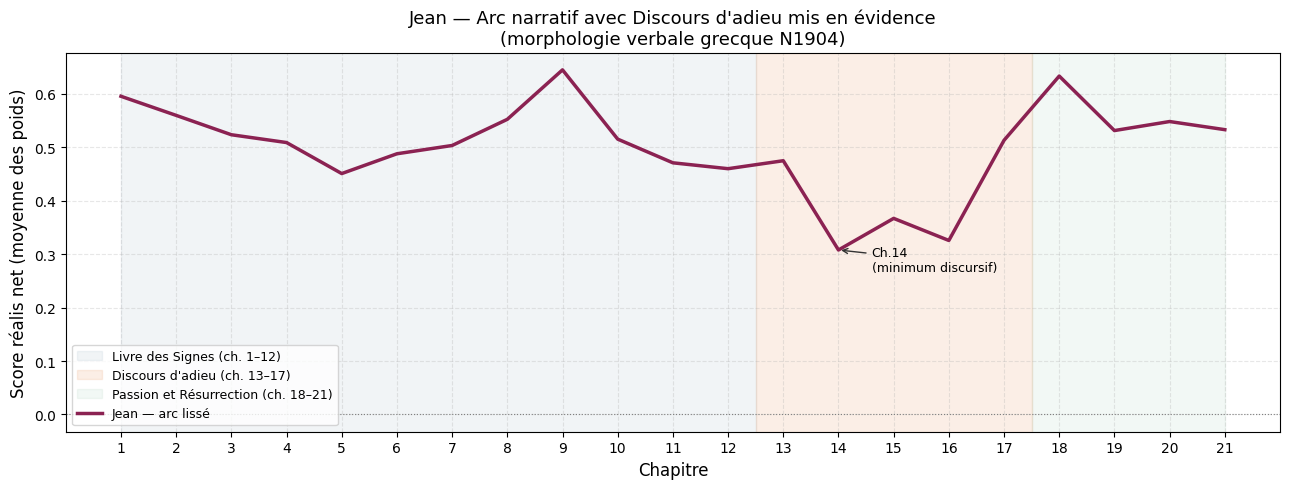

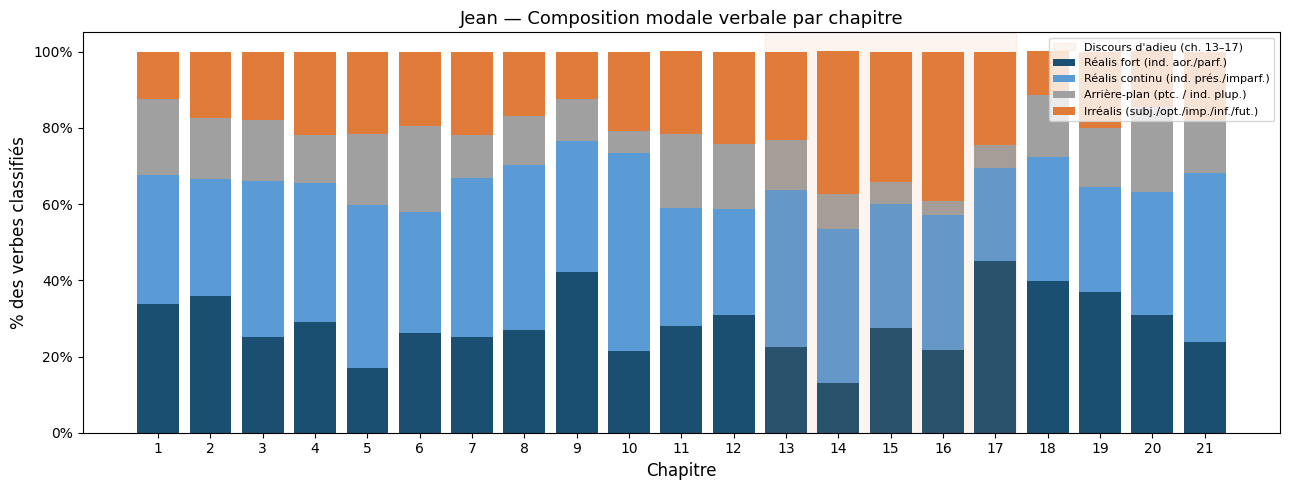

In [34]:
df_john = dfs["John"]

# Définition des trois sections structurelles de Jean
SECTIONS = {
    "Livre des Signes (ch. 1–12)":        range(1, 13),
    "Discours d'adieu (ch. 13–17)":       range(13, 18),
    "Passion et Résurrection (ch. 18–21)": range(18, 22),
}

print("Jean — Score réalis net par section")
print("=" * 45)
for section_name, ch_range in SECTIONS.items():
    section_df = df_john[df_john["chapter"].isin(ch_range)]
    mean_score    = section_df["net_score"].mean()
    mean_irrealis = section_df["irrealis_pct"].mean()
    mean_strong   = section_df["realis_strong_pct"].mean()
    print(f"\n{section_name}")
    print(f"  Score réalis net moyen     : {mean_score:.3f}")
    print(f"  Réalis fort moyen (%)      : {mean_strong:.1f}%")
    print(f"  Irréalis moyen (%)         : {mean_irrealis:.1f}%")

# ── Graphique Jean chapitre par chapitre avec zones colorées ──
fig, ax = plt.subplots(figsize=(13, 5))

john_chapters = df_john["chapter"].tolist()
john_scores   = df_john["net_score"].values
john_smoothed = savgol_filter(john_scores, window_length=3, polyorder=2)

# Zones de fond par section
ax.axvspan(1,    12.5, alpha=0.06, color="#1a4f72", label="Livre des Signes (ch. 1–12)")
ax.axvspan(12.5, 17.5, alpha=0.12, color="#e07b39", label="Discours d'adieu (ch. 13–17)")
ax.axvspan(17.5, 21,   alpha=0.06, color="#2e8b57", label="Passion et Résurrection (ch. 18–21)")

# Courbes brute et lissée
ax.plot(john_chapters, john_scores,
        color="#8b2252", linewidth=1, linestyle="--", alpha=0.4)
ax.plot(john_chapters, john_smoothed,
        color="#8b2252", linewidth=2.5, label="Jean — arc lissé")

# Annotation du creux
trough_ch = int(df_john.loc[df_john.net_score.idxmin(), "chapter"])
ax.annotate(
    f"Ch.{trough_ch}\n(minimum discursif)",
    xy=(trough_ch, john_smoothed[trough_ch - 1]),
    xytext=(trough_ch + 0.6, john_smoothed[trough_ch - 1] - 0.04),
    fontsize=9, arrowprops=dict(arrowstyle="->", color="#333")
)

# Frontière réalis/irréalis
ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set_xlabel("Chapitre", fontsize=12)
ax.set_ylabel("Score réalis net (moyenne des poids)", fontsize=12)
ax.set_title(
    "Jean — Arc narratif avec Discours d'adieu mis en évidence\n(morphologie verbale grecque N1904)",
    fontsize=13
)
ax.set_xticks(john_chapters)
ax.legend(fontsize=9, loc="lower left")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# ── Stacked bar de Jean, même palette que Marc ──
fig2, ax2 = plt.subplots(figsize=(13, 5))
bottom2 = [0.0] * len(john_chapters)

for col, label, color in zip(STACK_COLS, STACK_LABELS, COLORS.values()):
    vals = df_john[col].tolist()
    ax2.bar(john_chapters, vals, bottom=bottom2, label=label, color=color, width=0.8)
    bottom2 = [b + v for b, v in zip(bottom2, vals)]

# Mise en évidence du bloc Discours d'adieu
ax2.axvspan(12.6, 17.4, alpha=0.08, color="#e07b39", label="Discours d'adieu (ch. 13–17)")

ax2.set_xlabel("Chapitre", fontsize=12)
ax2.set_ylabel("% des verbes classifiés", fontsize=12)
ax2.set_title("Jean — Composition modale verbale par chapitre", fontsize=13)
ax2.set_xticks(john_chapters)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()